In [1]:
#### ZELL WITH COMBIPRECIP DATA 

In [1]:
import sys
sys.path.append("/storage/homefs/ge24z347/LISFLOOD_FP_8_1/src")
import importlib
import rasterio
import DEM_processing  # Import your updated module
import lisflood_inputdata
import flow_depth_plotting # Import your updated module

importlib.reload(DEM_processing)  # Reload the updated module
importlib.reload(lisflood_inputdata)
importlib.reload(flow_depth_plotting)  # Reload the updated module
import geopandas as gpd
import pandas as pd

In [1]:
import xarray as xr

# Replace with the path to your NetCDF file
# Open the dataset
ds_Zell = xr.open_dataset('/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m.nc', decode_times=False)
ds_Zell 

<xarray.Dataset> Size: 968B
Dimensions:         (time: 13, x: 4, y: 4)
Coordinates:
  * time            (time) float64 104B 0.0 1.0 2.0 3.0 ... 9.0 10.0 11.0 12.0
  * x               (x) float32 16B 2.702e+06 2.704e+06 2.704e+06 2.706e+06
  * y               (y) float32 16B 1.258e+06 1.256e+06 1.256e+06 1.254e+06
Data variables:
    rainfall_depth  (time, y, x) float32 832B ...
Attributes:
    description:  Cropped deterministic CPC rainfall
    history:      Created on 2025-09-03
    source:       CPC deterministic forecast cropped to DEM footprint

In [20]:
import xarray as xr

# Replace with the path to your NetCDF file
# Open the dataset
ds_Liestal = xr.open_dataset('/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Liestal_2m/Liestal_2m.nc', decode_times=False)
ds_Liestal

<xarray.Dataset> Size: 780B
Dimensions:         (time: 11, x: 4, y: 4)
Coordinates:
  * time            (time) float32 44B 0.0 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0 10.0
  * x               (x) float32 16B 2.62e+06 2.62e+06 2.622e+06 2.622e+06
  * y               (y) float32 16B 1.26e+06 1.26e+06 1.258e+06 1.258e+06
Data variables:
    rainfall_depth  (time, y, x) float32 704B ...
Attributes:
    description:  Cropped deterministic CPC rainfall
    history:      Created on 2025-07-03
    source:       CPC deterministic forecast cropped to DEM footprint

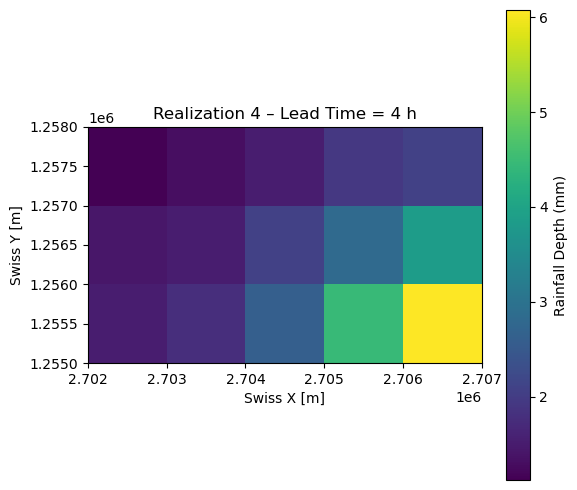

In [4]:
import xarray as xr
import matplotlib.pyplot as plt

# 1) Open the file
ds_Zell = xr.open_dataset('/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m.nc', decode_times=False)
# 2) Select the 4 h lead
rain4h = ds_Zell["rainfall_depth"].sel(time=8)

# 3) Plot
plt.figure(figsize=(6,5))
rain4h.plot(
    cmap="viridis",
    cbar_kwargs={"label":"Rainfall Depth (mm)"}
)
plt.title("Realization 4 – Lead Time = 4 h")
plt.xlabel("Swiss X [m]")
plt.ylabel("Swiss Y [m]")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()


In [1]:
import rasterio
import xarray as xr

# --- DEM bounds ---
dem_file = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m.dem"
with rasterio.open(dem_file) as src:
    dem_bounds = src.bounds   # (minx, miny, maxx, maxy)
    dem_res = src.res         # (xres, yres)
    print("DEM bounds:", dem_bounds)
    print("DEM resolution:", dem_res)

# --- NetCDF bounds ---
ds = xr.open_dataset("/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m/Zell_2m.nc", decode_times=False)

x = ds["x"].values
y = ds["y"].values
nc_bounds = (x.min(), y.min(), x.max(), y.max())
print("NetCDF bounds:", nc_bounds)

print("NetCDF resolution (approx):", (x[1] - x[0], y[1] - y[0]))

DEM bounds: BoundingBox(left=2701000.0, bottom=1255000.0, right=2707000.0, top=1259000.0)
DEM resolution: (2.0, 2.0)
NetCDF bounds: (np.float32(2701500.0), np.float32(1255500.0), np.float32(2707500.0), np.float32(1258500.0))
NetCDF resolution (approx): (np.float32(1000.0), np.float32(-1000.0))
